In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [51]:
df = pd.read_csv('/content/Sales Analysis.csv')

In [52]:
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,Day,Month,Year,CustomerName,State,City
0,B-26035,"$2,404.00",$253.00,15,Electronics,Laptops,COD,31-12-2021,31,12,2021,Megan Mack,Texas,Austin
1,B-26035,"$1,281.00",$340.00,3,Electronics,Electronic Games,Debit Card,31-12-2021,31,12,2021,Megan Mack,Texas,Austin
2,B-25715,"$6,089.00",$139.00,19,Furniture,Tables,Debit Card,31-12-2020,31,12,2020,Alicia Vincent,Ohio,Cincinnati
3,B-25715,"$2,586.00",$800.00,16,Furniture,Tables,UPI,31-12-2020,31,12,2020,Alicia Vincent,Ohio,Cincinnati
4,B-25715,"$3,757.00","$1,626.00",9,Office Supplies,Paper,UPI,31-12-2020,31,12,2020,Alicia Vincent,Ohio,Cincinnati


In [53]:
df.columns

Index(['Order ID', ' Amount ', ' Profit ', 'Quantity', 'Category',
       'Sub-Category', 'PaymentMode', 'Order Date', 'Day', 'Month', 'Year',
       'CustomerName', 'State', 'City'],
      dtype='object')

In [54]:
df.shape

(1194, 14)

In [55]:
df.isnull().sum()

,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
Day,0
Month,0


In [56]:
df.describe()

,Quantity,Day,Month,Year
count,1194.000000,1194.000000,1194.00000,1194.000000
mean,10.674204,16.015075,6.71273,2022.240369
std,5.777102,8.561387,3.48755,1.424847
min,1.000000,1.000000,1.00000,2020.000000
25%,6.000000,8.000000,4.00000,2021.000000
50%,11.000000,16.000000,7.00000,2022.000000
75%,16.000000,23.000000,10.00000,2023.000000
max,20.000000,31.000000,12.00000,2025.000000


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1    Amount       1194 non-null   object
 2    Profit       1194 non-null   object
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   Day           1194 non-null   int64 
 9   Month         1194 non-null   int64 
 10  Year          1194 non-null   int64 
 11  CustomerName  1194 non-null   object
 12  State         1194 non-null   object
 13  City          1194 non-null   object
dtypes: int64(4), object(10)
memory usage: 130.7+ KB


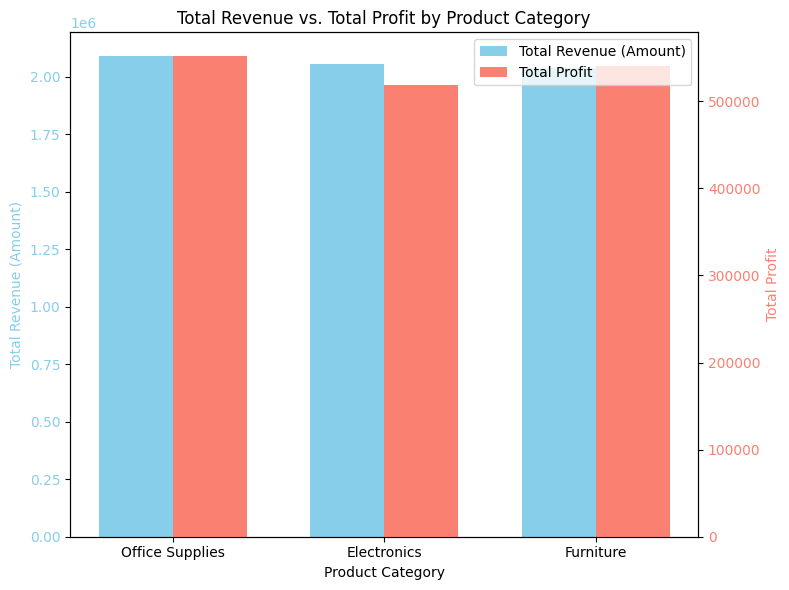

In [58]:
df.columns = df.columns.str.strip()

#  Data Cleaning and Metric Derivation

# Clean 'Amount' and 'Profit' columns: remove currency symbols ('$'), thousands separators (','),
# quotes ('"'), and convert the strings to floating-point numbers.
df['Amount'] = df['Amount'].astype(str).str.replace(r'[$,"]', '', regex=True).str.strip().astype(float)
df['Profit'] = df['Profit'].astype(str).str.replace(r'[$,"]', '', regex=True).str.strip().astype(float)

df['Year'] = df['Year'].astype(int)

# Formula: (Profit / Amount) * 100
df['Profit Margin (%)'] = np.where(
    df['Amount'] != 0,
    (df['Profit'] / df['Amount']) * 100,
    0
)

# Plot 1: Total Revenue vs. Total Profit by Product Category (Dual Axis Bar Chart)

category_summary = df.groupby('Category')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))
bar_width = 0.35
x = np.arange(len(category_summary.index))

# Plot Revenue on the primary axis (ax1)
rects1 = ax1.bar(x - bar_width/2, category_summary['Amount'], bar_width, label='Total Revenue (Amount)', color='skyblue')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Total Revenue (Amount)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(category_summary.index, rotation=0)

# Secondary y-axis for Profit (ax2)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + bar_width/2, category_summary['Profit'], bar_width, label='Total Profit', color='salmon')
ax2.set_ylabel('Total Profit', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

plt.title('Total Revenue vs. Total Profit by Product Category')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')
plt.show()

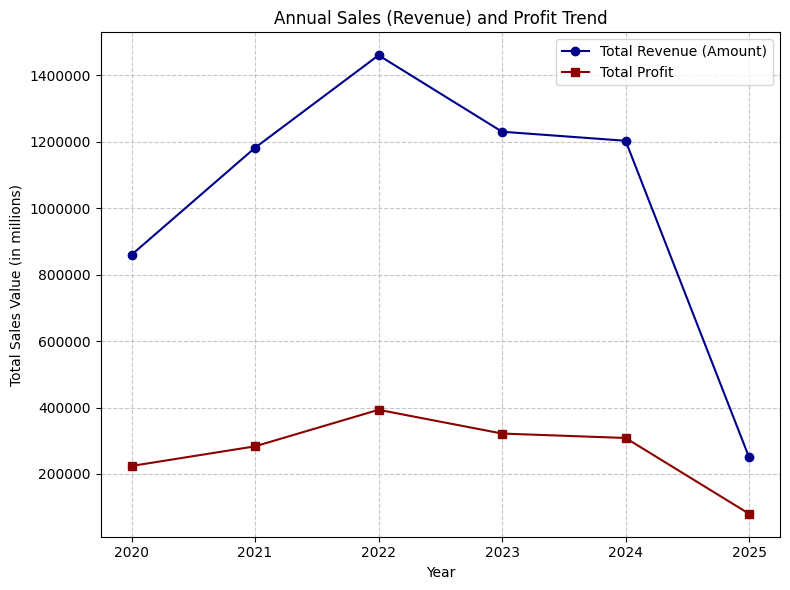

In [59]:
# Plot 3: Annual Sales and Profit Trend (Line Plot)

annual_trend = df.groupby('Year')[['Amount', 'Profit']].sum()

plt.figure(figsize=(8, 6))
plt.plot(annual_trend.index, annual_trend['Amount'], marker='o', label='Total Revenue (Amount)', color='darkblue')
plt.plot(annual_trend.index, annual_trend['Profit'], marker='s', label='Total Profit', color='darkred')

plt.xlabel('Year')
plt.ylabel('Total Sales Value (in millions)')
plt.title('Annual Sales (Revenue) and Profit Trend')
plt.xticks(annual_trend.index)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

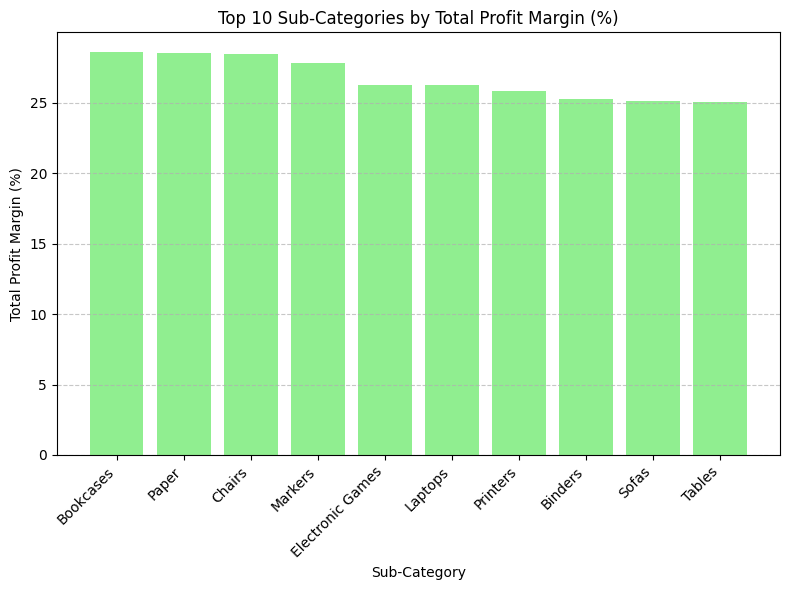

In [60]:
# Plot 2: Top 10 Sub-Categories by Total Profit Margin (%) (Bar Chart)

sub_category_summary = df.groupby('Sub-Category')[['Amount', 'Profit']].sum()
sub_category_summary['Profit Margin (%)'] = (sub_category_summary['Profit'] / sub_category_summary['Amount']) * 100
top_margin_sub_categories = sub_category_summary.sort_values(by='Profit Margin (%)', ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.bar(top_margin_sub_categories.index, top_margin_sub_categories['Profit Margin (%)'], color='lightgreen')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit Margin (%)')
plt.title('Top 10 Sub-Categories by Total Profit Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

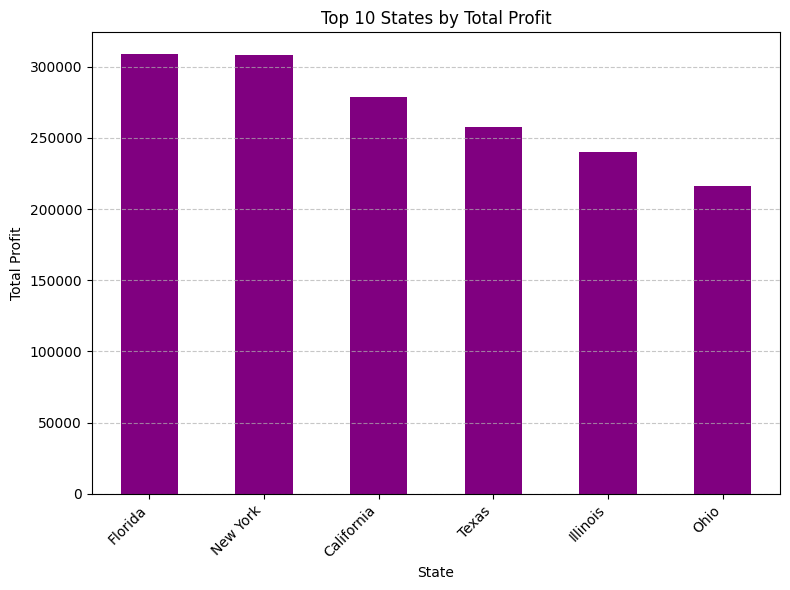

In [61]:
# Plot 4: Top 10 States by Total Profit (Bar Chart)

state_profit = df.groupby('State')['Profit'].sum().nlargest(10)

plt.figure(figsize=(8, 6))
state_profit.plot(kind='bar', color='purple')
plt.title('Top 10 States by Total Profit')
plt.xlabel('State')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

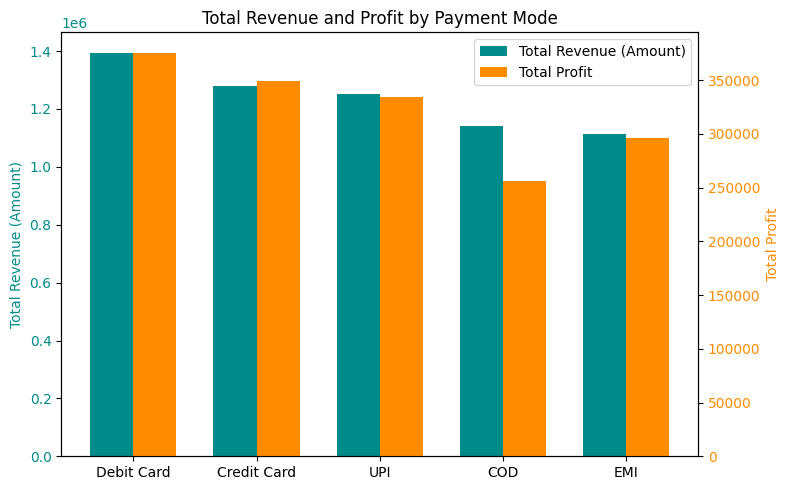

In [62]:
# Plot 6: Revenue and Profit by Payment Mode (Dual Axis Bar Chart)

payment_summary = df.groupby('PaymentMode')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Amount (Revenue)
bar_width = 0.35
x = np.arange(len(payment_summary.index))
rects1 = ax1.bar(x - bar_width/2, payment_summary['Amount'], bar_width, label='Total Revenue (Amount)', color='darkcyan')
ax1.set_ylabel('Total Revenue (Amount)', color='darkcyan')
ax1.tick_params(axis='y', labelcolor='darkcyan')
ax1.set_xticks(x)
ax1.set_xticklabels(payment_summary.index, rotation=0)

# Secondary y-axis for Profit
ax2 = ax1.twinx()
rects2 = ax2.bar(x + bar_width/2, payment_summary['Profit'], bar_width, label='Total Profit', color='darkorange')
ax2.set_ylabel('Total Profit', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Total Revenue and Profit by Payment Mode')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')
# plt.show()

In [63]:
# 1. Average Order Metrics
# Group by Order ID to get total amount and profit per unique order
order_summary = df.groupby('Order ID').agg({
    'Amount': 'sum',
    'Profit': 'sum'
})

aov = order_summary['Amount'].mean()
appo = order_summary['Profit'].mean() # Average Profit Per Order

# 2. Top 5 Cities by Total Revenue
city_revenue = df.groupby('City')['Amount'].sum().nlargest(5).reset_index()

# 3. Average Quantity Sold per Order Line
avg_quantity_per_line = df['Quantity'].mean()

# 4. Most Frequent Selling Sub-Category (by count in order lines)
most_frequent_subcategory = df['Sub-Category'].mode().iloc[0]
most_frequent_subcategory_count = df['Sub-Category'].value_counts().iloc[0]


# Print all calculated results:
print(f"Average Order Value (AOV): ${aov:.2f}")
print(f"Average Profit per Order: ${appo:.2f}")
print(f"Average Quantity Sold per Order Line: {avg_quantity_per_line:.2f} units")
print(f"Most Frequently Sold Sub-Category: {most_frequent_subcategory} ({most_frequent_subcategory_count} units sold)")

Average Order Value (AOV): $11302.81
Average Profit per Order: $2944.60
Average Quantity Sold per Order Line: 10.67 units
Most Frequently Sold Sub-Category: Tables (122 units sold)


In [64]:

print("\nTop 5 Cities by Total Revenue:")
print(city_revenue.to_markdown(index=False, floatfmt=".2f"))


Top 5 Cities by Total Revenue:
| City          |    Amount |
|:--------------|----------:|
| Orlando       | 452158.00 |
| San Francisco | 440000.00 |
| Buffalo       | 418514.00 |
| Rochester     | 407291.00 |
| Dallas        | 390144.00 |


In [65]:
# Convert 'Order Date' to datetime using the expected format 'DD-MM-YYYY'
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')

# Extract Day of Week Name (Now this will work)
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Month'] = df['Order Date'].dt.month # Extract month from the datetime object

# 5. Monthly Sales and Profit Trend (Seasonality Analysis)

# Group by the extracted Month (1-12)
month_order = list(range(1, 13))
monthly_summary = df.groupby('Month')[['Amount', 'Profit']].sum().reindex(month_order, fill_value=0)

# Format index for clearer presentation
monthly_summary.index = monthly_summary.index.map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

print(" 1. Monthly Sales (Revenue) and Profit Trend (Seasonality)")
print(monthly_summary.to_markdown(floatfmt=".2f"))

--- 1. Monthly Sales (Revenue) and Profit Trend (Seasonality) ---
| Month   |    Amount |    Profit |
|:--------|----------:|----------:|
| Jan     | 392678.00 | 110381.00 |
| Feb     | 450672.00 | 118941.00 |
| Mar     | 497247.00 | 152739.00 |
| Apr     | 567882.00 | 139373.00 |
| May     | 581943.00 | 129629.00 |
| Jun     | 529028.00 | 141845.00 |
| Jul     | 497410.00 | 132117.00 |
| Aug     | 517830.00 | 143289.00 |
| Sep     | 408236.00 | 111244.00 |
| Oct     | 632521.00 | 155154.00 |
| Nov     | 451814.00 | 116169.00 |
| Dec     | 655378.00 | 159816.00 |


In [66]:
# 6. Day of Week Performance
day_order_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = df.groupby('DayOfWeek')[['Amount', 'Profit']].sum()

# Reindex to enforce correct day order and calculate profit margin
dow_summary = dow_summary.reindex(day_order_names, fill_value=0)
dow_summary['Profit Margin (%)'] = (dow_summary['Profit'] / dow_summary['Amount']) * 100

print("\n 2. Day of Week Performance ")
print(dow_summary.to_markdown(floatfmt=".2f"))


--- 2. Day of Week Performance ---
| DayOfWeek   |    Amount |    Profit |   Profit Margin (%) |
|:------------|----------:|----------:|--------------------:|
| Monday      | 921501.00 | 254891.00 |               27.66 |
| Tuesday     | 961229.00 | 247123.00 |               25.71 |
| Wednesday   | 861520.00 | 230287.00 |               26.73 |
| Thursday    | 966921.00 | 260700.00 |               26.96 |
| Friday      | 842370.00 | 198304.00 |               23.54 |
| Saturday    | 794497.00 | 200673.00 |               25.26 |
| Sunday      | 834601.00 | 218719.00 |               26.21 |
